# Complete Pairwise Tanimoto Fold-Distance Plots — Hi Tasks

This notebook generates figures from the fold-distance tables computed in:

`01_tanimoto_distance_tables_hi.ipynb`

No fingerprints, feature importances or distances are recomputed here.

Loaded tables:

- `fold_distance_summary.csv`
- `fold_distance_nn_distributions.csv`
- `fold_distance_activity_vs_random_bits_summary.csv`

The main plotted metric is the complete cross-fold pairwise Tanimoto distance. Nearest-neighbour histograms are shown only as a diagnostic.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()
    current = start
    while current != current.parent:
        if all((current / d).exists() for d in ["data", "utils", "training"]):
            return current
        current = current.parent
    raise RuntimeError("Could not find project root.")


PROJECT_ROOT = find_project_root()

TASK = "hi"
DATASETS_MAIN = ["drd2", "hiv", "sol"]
DATASETS = DATASETS_MAIN

DATASET_LABELS = {"drd2": "DRD2", "hiv": "HIV", "sol": "Sol"}

K_VALUES = [10, 20, 50, 100, 200]

OUT_ROOT = PROJECT_ROOT / "results" / "results_fold_distance_tanimoto" / TASK
FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

DATASET_COLORS = {"drd2": "#4C78A8", "hiv": "#F58518", "sol": "#B279A2"}

print("Plot notebook setup completed.")
print(f"OUT_ROOT: {OUT_ROOT}")
print(f"FIG_ROOT: {FIG_ROOT}")

Plot notebook setup completed.
OUT_ROOT: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi
FIG_ROOT: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures


In [2]:
dist_path = OUT_ROOT / "fold_distance_summary.csv"
hist_path = OUT_ROOT / "fold_distance_nn_distributions.csv"
summary_path = OUT_ROOT / "fold_distance_activity_vs_random_bits_summary.csv"

if not dist_path.exists():
    raise FileNotFoundError(f"Missing distance table: {dist_path}")

if not hist_path.exists():
    raise FileNotFoundError(f"Missing NN histogram table: {hist_path}")

if not summary_path.exists():
    raise FileNotFoundError(f"Missing final summary table: {summary_path}")

dist_all = pd.read_csv(dist_path)
hist_all = pd.read_csv(hist_path)
final_summary = pd.read_csv(summary_path)

print("Loaded plotting tables.")
print(f"dist_all      : {dist_all.shape}")
print(f"hist_all      : {hist_all.shape}")
print(f"final_summary : {final_summary.shape}")

display(dist_all.head())

Loaded plotting tables.
dist_all      : (1494, 23)
hist_all      : (630568, 7)
final_summary : (18, 16)


,dataset,dataset_label,pair,space,k,model,bit_source,activity_protocol,activity_fold,bit_repeat,...,nn_B_to_A_mean,wasserstein_nd,valid_molecule_fraction,n_valid_molecules,n_total_molecules,pairwise_distance,valid_pair_fraction,n_valid_pairs,n_total_pairs,pairwise_mode
0,drd2,DRD2,F1_vs_F2,full_ecfp4,2048,SVM,full_ecfp4,NaN,NaN,NaN,...,0.699229,8.002976,1.000000,2385,2385,0.852592,1.000000,1422054,1422054,complete
1,drd2,DRD2,F1_vs_F2,global_top10,10,SVM,global_activity,pooled,NaN,NaN,...,0.051887,0.861634,0.963522,2298,2385,0.637233,0.998670,1420162,1422054,complete
2,drd2,DRD2,F1_vs_F2,ood_top10,10,SVM,ood_activity,ood,1.0,NaN,...,0.022899,0.829200,0.961426,2293,2385,0.502789,0.998569,1420019,1422054,complete
3,drd2,DRD2,F1_vs_F2,random_top10,10,SVM,random_shuffle_activity,random,1.0,NaN,...,0.030112,0.487541,0.979874,2337,2385,0.534660,0.999620,1421514,1422054,complete
4,drd2,DRD2,F1_vs_F2,random_bits_top10,10,SVM,random_bits,NaN,NaN,0.0,...,0.003527,0.142175,0.150943,360,2385,0.981522,0.279141,396954,1422054,complete


In [3]:
required_dist_cols = [
    "dataset",
    "pair",
    "space",
    "k",
    "bit_source",
    "pairwise_distance",
    "valid_molecule_fraction",
    "valid_pair_fraction",
]

missing = [c for c in required_dist_cols if c not in dist_all.columns]
if missing:
    raise ValueError(f"Missing required columns in dist_all: {missing}")

if dist_all["pairwise_distance"].notna().sum() == 0:
    raise RuntimeError("All pairwise_distance values are NaN.")

assert "kdr" not in set(dist_all["dataset"]), "KDR found in Tanimoto plot table."

print("Sanity checks passed.")
print(
    f"Finite pairwise_distance: "
    f"{dist_all['pairwise_distance'].notna().sum()}/{len(dist_all)}"
)

Sanity checks passed.
Finite pairwise_distance: 1494/1494


In [4]:
def set_plot_style():
    mpl.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 9,
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 8.5,
            "ytick.labelsize": 8.5,
            "legend.fontsize": 8.5,
            "figure.dpi": 150,
            "savefig.dpi": 600,
            "axes.linewidth": 0.8,
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )


def stable_seed(*parts, base: int = 42) -> int:
    import zlib

    s = "|".join(str(p) for p in parts) + f"|{base}"
    return zlib.crc32(s.encode("utf-8")) & 0xFFFFFFFF


def local_rng(*parts) -> np.random.Generator:
    return np.random.default_rng(stable_seed(*parts))


set_plot_style()
print("Plot style configured.")

Plot style configured.


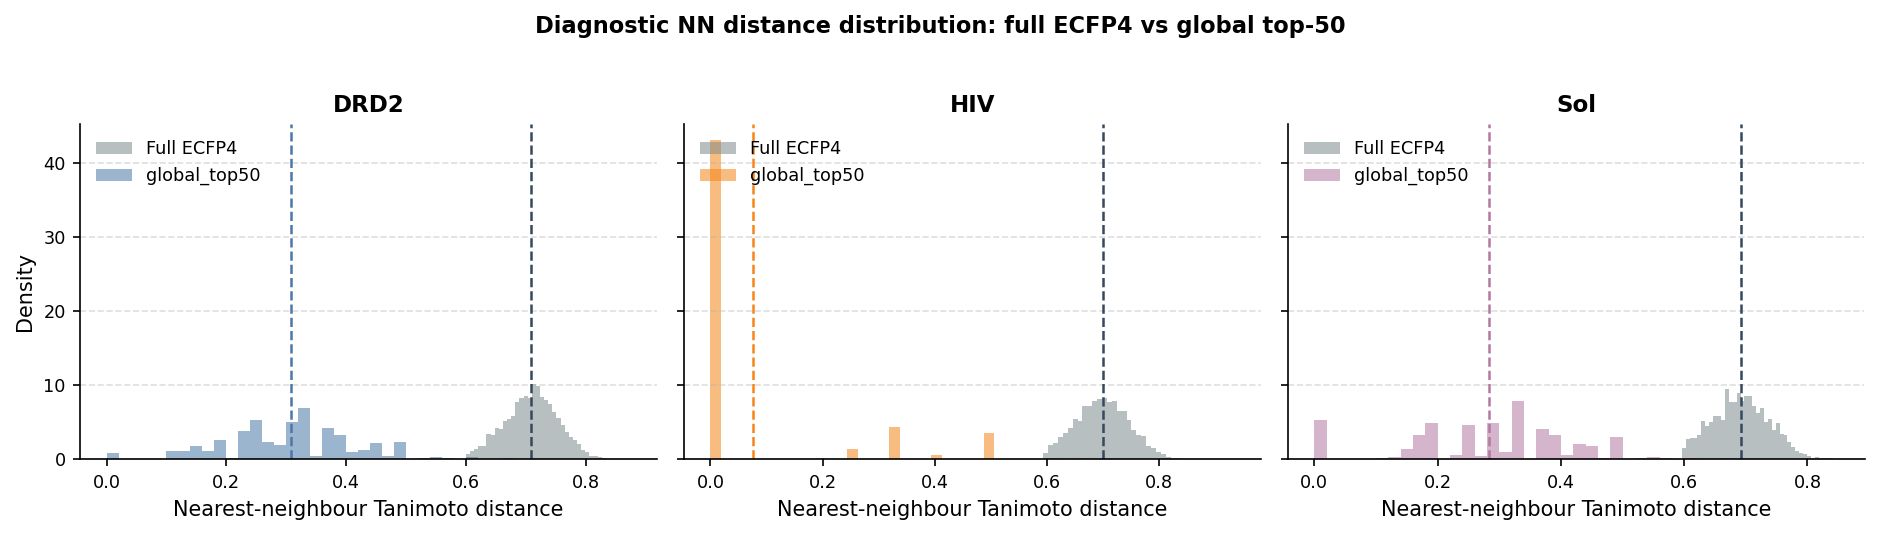

Figure 1 generated.


In [ ]:
def fig_distance_histograms(
    hist_all: pd.DataFrame, k_show: int = 50, source_prefix: str = "global"
):
    set_plot_style()
    datasets = [d for d in DATASETS if d in hist_all["dataset"].unique()]
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.4), sharey=True, squeeze=False)

    restricted_space = f"{source_prefix}_top{k_show}"

    for ax, ds in zip(axes[0], datasets):
        full = hist_all[
            (hist_all["dataset"] == ds) & (hist_all["space"] == "full_ecfp4")
        ]
        rest = hist_all[
            (hist_all["dataset"] == ds) & (hist_all["space"] == restricted_space)
        ]

        if len(full) > 0:
            ax.hist(
                full["nn_distance"],
                bins=40,
                alpha=0.55,
                color="#7F8C8D",
                label="Full ECFP4",
                density=True,
            )
            ax.axvline(full["nn_distance"].mean(), ls="--", lw=1.2, color="#34495E")

        if len(rest) > 0:
            ax.hist(
                rest["nn_distance"],
                bins=40,
                alpha=0.55,
                color=DATASET_COLORS.get(ds, "C0"),
                label=f"{restricted_space}",
                density=True,
            )
            ax.axvline(
                rest["nn_distance"].mean(),
                ls="--",
                lw=1.2,
                color=DATASET_COLORS.get(ds, "C0"),
            )

        ax.set_title(DATASET_LABELS.get(ds, ds), fontweight="bold")
        ax.set_xlabel("Nearest-neighbour Tanimoto distance")
        ax.legend(loc="upper left", frameon=False)
        ax.grid(axis="y", ls="--", alpha=0.4)

    axes[0, 0].set_ylabel("Density")
    fig.suptitle(
        f"Diagnostic NN distance distribution: full ECFP4 vs {source_prefix} top-{k_show}",
        fontweight="bold",
        y=1.03,
    )
    fig.tight_layout()
    fname = FIG_ROOT / f"fig1_nn_hist_full_vs_{source_prefix}_top{k_show}"
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)


fig_distance_histograms(hist_all, k_show=50, source_prefix="global")

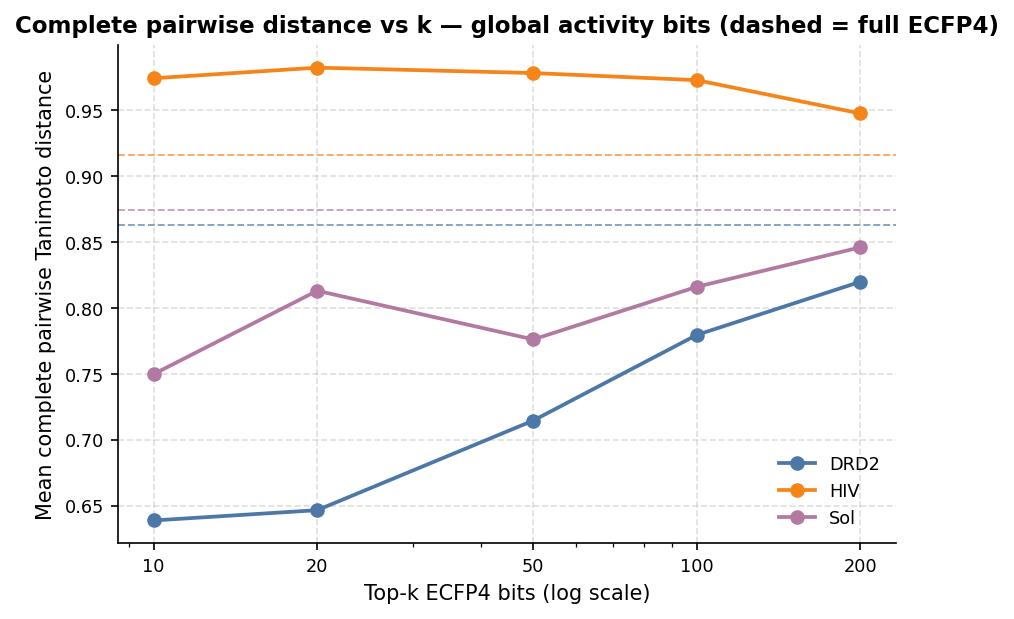

Figure 2 generated.


In [ ]:
def fig_distance_vs_k(dist_all: pd.DataFrame, source_prefix: str = "global"):
    set_plot_style()

    src_map = {
        "global": "global_activity",
        "ood": "ood_activity",
        "random": "random_shuffle_activity",
    }
    bit_src = src_map[source_prefix]

    sub = dist_all[dist_all["bit_source"] == bit_src]
    full = dist_all[dist_all["bit_source"] == "full_ecfp4"]

    fig, ax = plt.subplots(figsize=(6.0, 4.2))
    for ds in DATASETS:
        sub_d = (
            sub[sub["dataset"] == ds]
            .groupby("k", as_index=False)["pairwise_distance"]
            .mean()
            .sort_values("k")
        )
        if sub_d.empty:
            continue
        ax.plot(
            sub_d["k"],
            sub_d["pairwise_distance"],
            marker="o",
            lw=1.8,
            color=DATASET_COLORS.get(ds, "C0"),
            label=DATASET_LABELS[ds],
        )

        full_d = full[full["dataset"] == ds]["pairwise_distance"].mean()
        if np.isfinite(full_d):
            ax.axhline(
                full_d, ls="--", lw=0.9, color=DATASET_COLORS.get(ds, "C0"), alpha=0.7
            )

    ax.set_xscale("log")
    ax.set_xticks(K_VALUES)
    ax.set_xticklabels([str(k) for k in K_VALUES])
    ax.set_xlabel("Top-k ECFP4 bits (log scale)")
    ax.set_ylabel("Mean complete pairwise Tanimoto distance")
    ax.set_title(
        f"Complete pairwise distance vs k — {source_prefix} activity bits "
        "(dashed = full ECFP4)",
        fontweight="bold",
    )
    ax.grid(ls="--", alpha=0.4)
    ax.legend(frameon=False)

    fname = FIG_ROOT / f"fig2_pairwise_distance_vs_k_{source_prefix}"
    fig.tight_layout()
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)


fig_distance_vs_k(dist_all, source_prefix="global")
print("Figure 2 generated.")

In [ ]:
def fig_valid_fraction_vs_k(dist_all: pd.DataFrame):
    set_plot_style()
    datasets = [d for d in DATASETS if d in dist_all["dataset"].unique()]
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.4), sharey=True, squeeze=False)

    series = [
        ("global_activity", "Global activity", "#2C3E50"),
        ("ood_activity", "OOD activity", "#2563EB"),
        ("random_shuffle_activity", "Random-shuffle activity", "#DC2626"),
        ("random_bits", "Random bits", "#95A5A6"),
    ]

    for ax, ds in zip(axes[0], datasets):
        for src, label, color in series:
            sub = (
                dist_all[(dist_all["dataset"] == ds) & (dist_all["bit_source"] == src)]
                .groupby("k", as_index=False)["valid_molecule_fraction"]
                .mean()
                .sort_values("k")
            )
            if sub.empty:
                continue
            ax.plot(
                sub["k"],
                sub["valid_molecule_fraction"],
                marker="o",
                lw=1.6,
                color=color,
                label=label,
            )

        ax.set_xscale("log")
        ax.set_xticks(K_VALUES)
        ax.set_xticklabels([str(k) for k in K_VALUES])
        ax.set_ylim(0, 1.02)
        ax.set_xlabel("Top-k bits (log scale)")
        ax.set_title(DATASET_LABELS.get(ds, ds), fontweight="bold")
        ax.grid(ls="--", alpha=0.4)
        ax.legend(frameon=False, fontsize=7.5)

    axes[0, 0].set_ylabel("Valid molecule fraction")
    fig.suptitle(
        "Restricted-space coverage: valid molecule fraction vs k",
        fontweight="bold",
        y=1.03,
    )
    fig.tight_layout()
    fname = FIG_ROOT / "fig6_valid_fraction_vs_k"
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)


fig_protocol_vs_k(dist_all)
print("Figure 3 generated.")

NameError: name 'fig_protocol_vs_k' is not defined

In [8]:
def fig_delta_heatmap(
    dist_all: pd.DataFrame, k_show: int = 50, source_prefix: str = "global"
):
    set_plot_style()
    src_map = {
        "global": "global_activity",
        "ood": "ood_activity",
        "random": "random_shuffle_activity",
    }
    bit_src = src_map[source_prefix]

    full = dist_all[dist_all["bit_source"] == "full_ecfp4"][
        ["dataset", "pair", "pairwise_distance"]
    ].rename(columns={"pairwise_distance": "full_distance"})

    rest = dist_all[(dist_all["bit_source"] == bit_src) & (dist_all["k"] == k_show)][
        ["dataset", "pair", "pairwise_distance"]
    ].rename(columns={"pairwise_distance": "restricted_distance"})

    merged = rest.merge(full, on=["dataset", "pair"], how="inner")
    merged["delta"] = merged["restricted_distance"] - merged["full_distance"]

    mat = (
        merged.pivot(index="dataset", columns="pair", values="delta")
        .reindex(DATASETS)
        .reindex(columns=[f"{a}_vs_{b}" for a, b in PAIRS])
    )

    vmax = float(np.nanmax(np.abs(mat.values))) or 0.001
    norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(5.6, 3.0))
    cmap = mpl.colormaps["RdBu_r"].copy()
    cmap.set_bad(color="lightgray")
    data = np.ma.masked_invalid(mat.values.astype(float))
    im = ax.imshow(data, cmap=cmap, norm=norm, aspect="auto", interpolation="nearest")

    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=0)
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels([DATASET_LABELS.get(d, d) for d in mat.index])

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iloc[i, j]
            if pd.notna(v):
                ax.text(
                    j,
                    i,
                    f"{v:+.2f}",
                    ha="center",
                    va="center",
                    fontsize=8.5,
                    fontweight="bold",
                    color="white" if abs(v) > 0.6 * vmax else "0.10",
                )

    cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.03)
    cbar.set_label("Δ complete pairwise distance (restricted − full)")
    ax.set_title(
        f"{source_prefix} top-{k_show} minus full ECFP4 — Δ complete pairwise Tanimoto distance",
        fontweight="bold",
        pad=8,
    )
    fig.tight_layout()
    fname = FIG_ROOT / f"fig4_pairwise_delta_heatmap_{source_prefix}_top{k_show}"
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [9]:
def fig_activity_vs_random_bits(dist_all: pd.DataFrame, k_show: int = 50):
    set_plot_style()
    datasets = [d for d in DATASETS if d in dist_all["dataset"].unique()]
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(4.4 * n, 3.6), sharey=True, squeeze=False)

    activity_sources = [
        ("global_activity", "Global activity", "#2C3E50"),
        ("ood_activity", "OOD activity", "#2563EB"),
        ("random_shuffle_activity", "Random-shuffle activity", "#DC2626"),
    ]

    for ax, ds in zip(axes[0], datasets):
        # Random-bit baseline (gray jitter + Q05/Q95 band + mean line at x=0).
        rb = dist_all[
            (dist_all["dataset"] == ds)
            & (dist_all["bit_source"] == "random_bits")
            & (dist_all["k"] == k_show)
        ]
        if not rb.empty:
            jitter = local_rng("jitter", ds, k_show).uniform(-0.18, 0.18, size=len(rb))
            ax.scatter(
                np.zeros(len(rb)) + jitter,
                rb["pairwise_distance"],
                s=14,
                color="#95A5A6",
                alpha=0.55,
                label="Random-bit baseline",
                zorder=2,
            )
            q05 = rb["pairwise_distance"].quantile(0.05)
            q95 = rb["pairwise_distance"].quantile(0.95)
            ax.axhspan(q05, q95, color="#BDC3C7", alpha=0.25, zorder=1)
            ax.hlines(
                rb["pairwise_distance"].mean(),
                -0.4,
                0.4,
                color="#7F8C8D",
                lw=1.4,
                zorder=3,
            )

        # Activity sources (global / OOD / random-shuffle) at x = 1, 2, 3.
        for offset, (src, label, color) in enumerate(activity_sources, start=1):
            sub = dist_all[
                (dist_all["dataset"] == ds)
                & (dist_all["bit_source"] == src)
                & (dist_all["k"] == k_show)
            ]
            if sub.empty:
                continue
            ax.scatter(
                np.full(len(sub), offset),
                sub["pairwise_distance"],
                s=70,
                color=color,
                edgecolor="black",
                linewidth=0.5,
                alpha=0.9,
                zorder=4,
                label=label,
            )
            ax.hlines(
                sub["pairwise_distance"].mean(),
                offset - 0.3,
                offset + 0.3,
                color=color,
                lw=2.0,
                zorder=5,
            )

        # Full ECFP4 reference (constant across x).
        full_d = dist_all[
            (dist_all["dataset"] == ds) & (dist_all["bit_source"] == "full_ecfp4")
        ]["pairwise_distance"].mean()
        if np.isfinite(full_d):
            ax.axhline(
                full_d,
                ls="--",
                lw=1.0,
                color="black",
                alpha=0.6,
                label="Full ECFP4 mean",
            )

        ax.set_xticks([0, 1, 2, 3])
        ax.set_xticklabels(
            [
                "Random\nbits",
                "Global\nactivity",
                "OOD\nactivity",
                "Random-shuffle\nactivity",
            ],
            fontsize=8,
        )
        ax.set_title(DATASET_LABELS.get(ds, ds), fontweight="bold")
        ax.grid(axis="y", ls="--", alpha=0.4)
        if ax is axes[0, 0]:
            ax.set_ylabel(f"Complete pairwise Tanimoto distance @ top-{k_show}")
        ax.legend(loc="lower right", fontsize=7.5, frameon=False)

    fig.suptitle(
        f"Activity top-{k_show} vs random-bit top-{k_show} baseline",
        fontweight="bold",
        y=1.03,
    )
    fig.tight_layout()
    fname = FIG_ROOT / f"fig5_pairwise_activity_vs_random_bits_top{k_show}"
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)